
===== PIPELINE START =====

 Video loaded successfully
 Total frames in video: 6663
 Processing started... please wait
 Done! Total saved frames: 445
Total frames: 445
Processing started...

denoising 1/445: frame_0.jpg


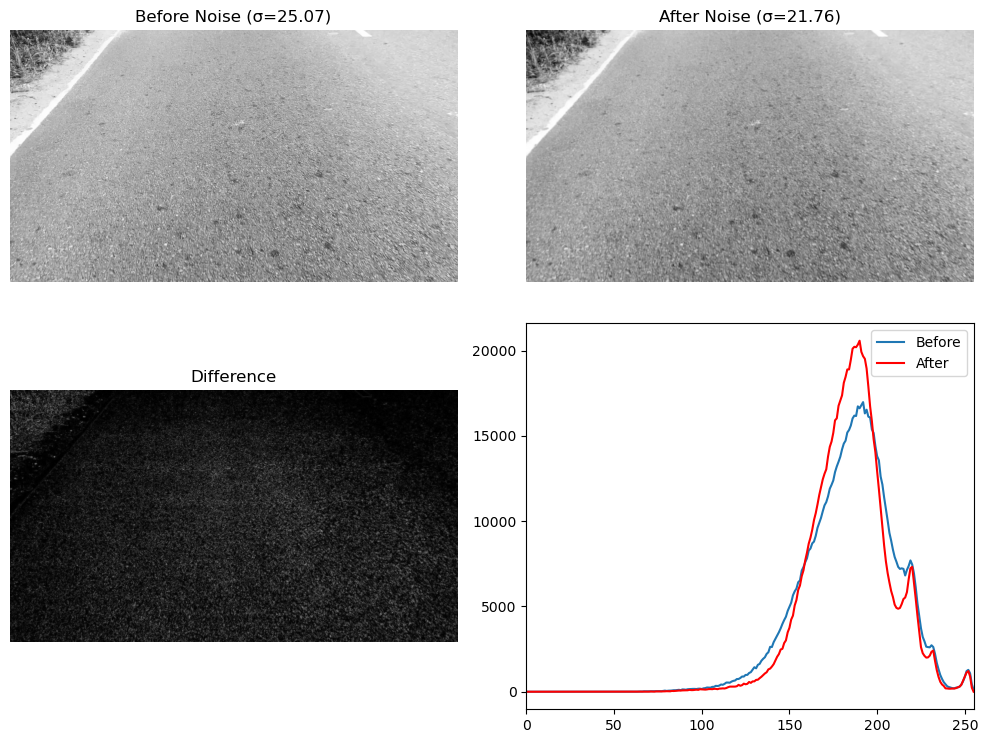

denoising 2/445: frame_1.jpg


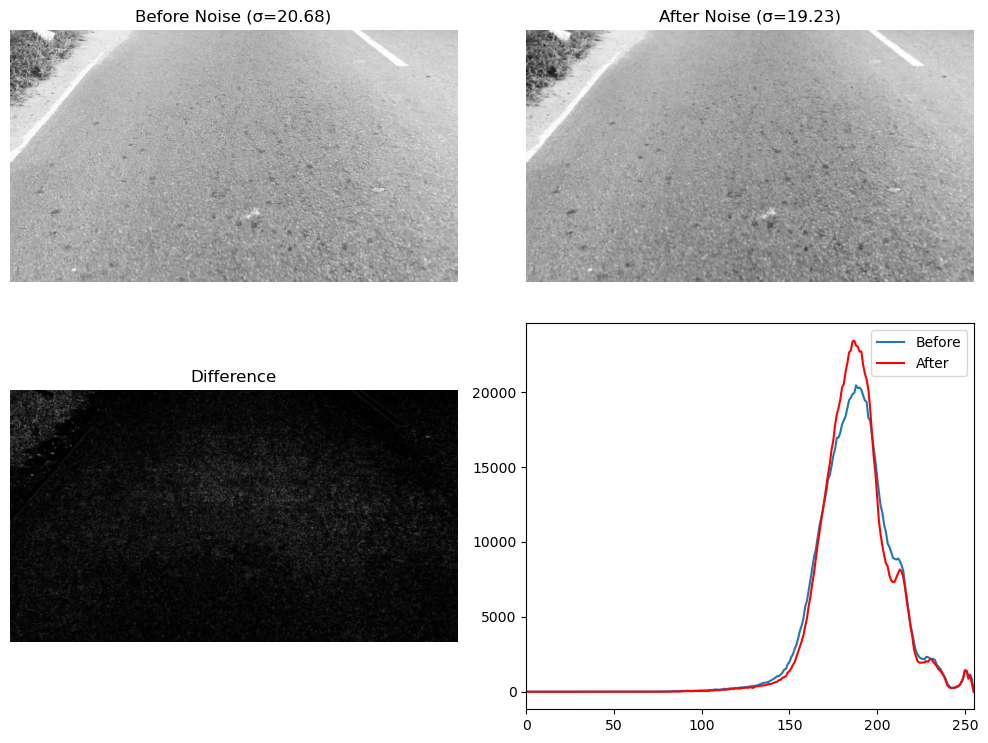

denoising 3/445: frame_10.jpg


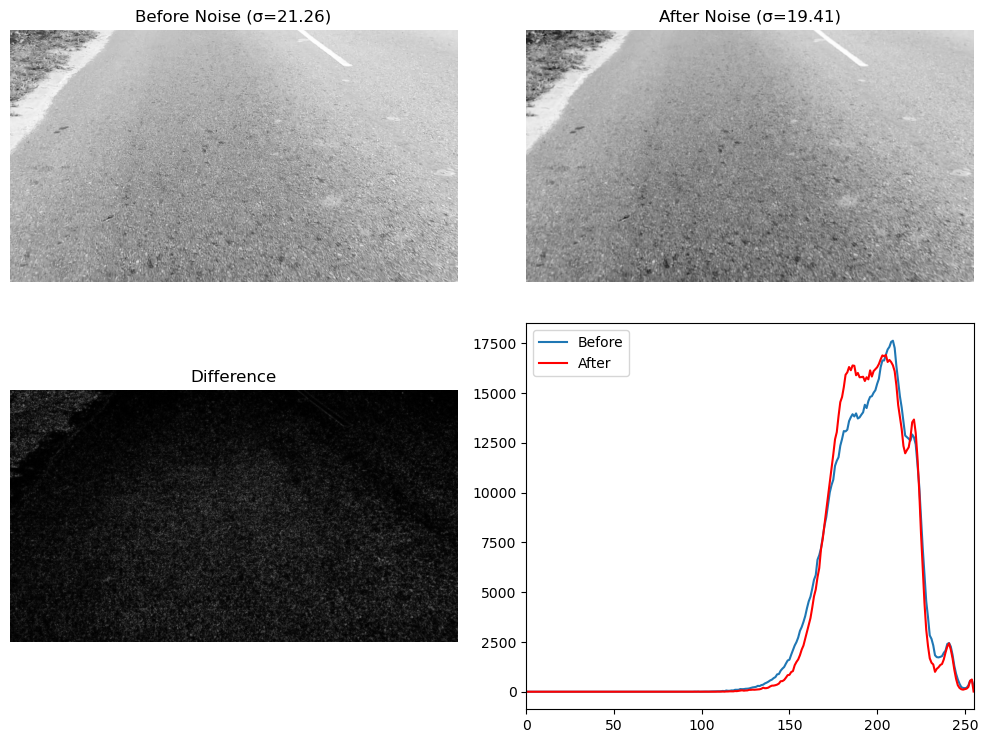

denoising 4/445: frame_100.jpg


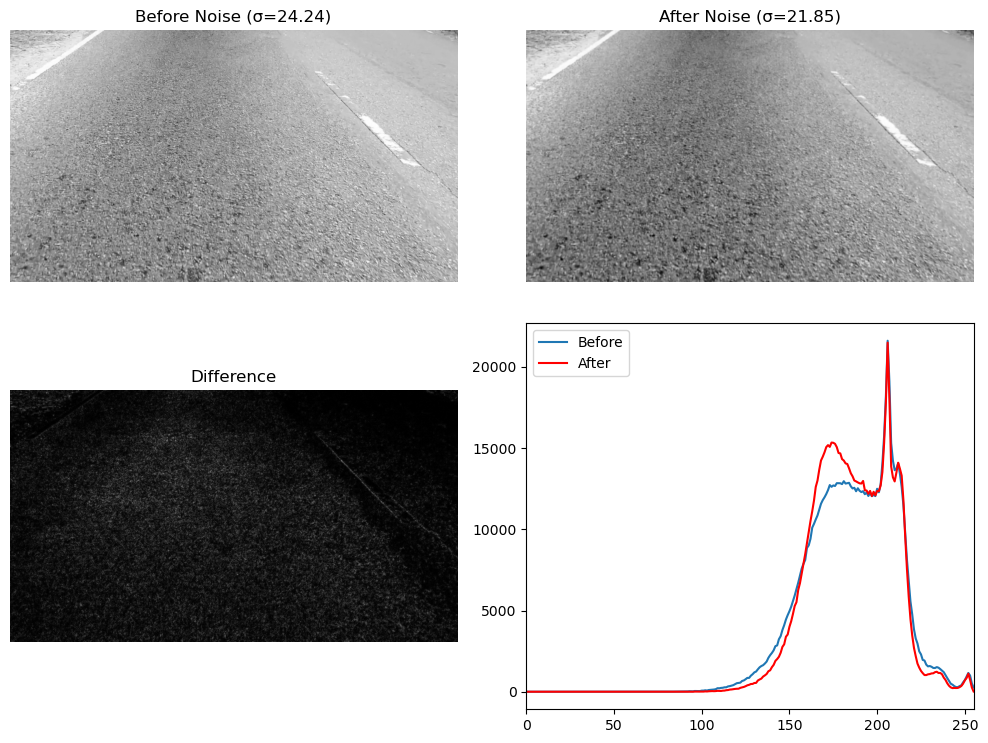

denoising 5/445: frame_101.jpg


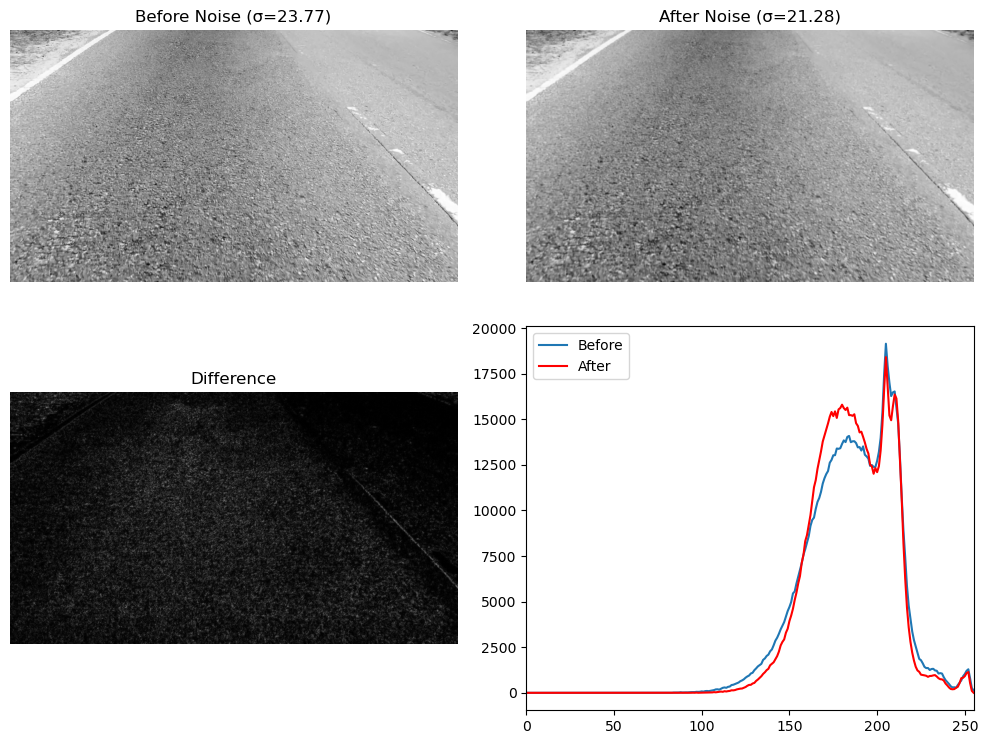

denoising 6/445: frame_102.jpg
denoising 7/445: frame_103.jpg
denoising 8/445: frame_104.jpg
denoising 9/445: frame_105.jpg
denoising 10/445: frame_106.jpg
denoising 11/445: frame_107.jpg
denoising 12/445: frame_108.jpg
denoising 13/445: frame_109.jpg
denoising 14/445: frame_11.jpg
denoising 15/445: frame_110.jpg
denoising 16/445: frame_111.jpg
denoising 17/445: frame_112.jpg
denoising 18/445: frame_113.jpg
denoising 19/445: frame_114.jpg
denoising 20/445: frame_115.jpg
denoising 21/445: frame_116.jpg
denoising 22/445: frame_117.jpg
denoising 23/445: frame_118.jpg
denoising 24/445: frame_119.jpg
denoising 25/445: frame_12.jpg
denoising 26/445: frame_120.jpg
denoising 27/445: frame_121.jpg
denoising 28/445: frame_122.jpg
denoising 29/445: frame_123.jpg
denoising 30/445: frame_124.jpg
denoising 31/445: frame_125.jpg
denoising 32/445: frame_126.jpg
denoising 33/445: frame_127.jpg
denoising 34/445: frame_128.jpg
denoising 35/445: frame_129.jpg
denoising 36/445: frame_13.jpg
denoising 37/44

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt


# =========================
# FOLDERS
# =========================

video_path = r"D:\image processing project\road.mp4"

frame_folder = r"D:\image processing project\frames"
gray_folder = r"D:\image processing project\gray_frames"

denoise_output = r"D:\image processing project\denoise_output"
denoise_comparisons = r"D:\image processing project\denoise_comparisons"

illuminated_folder = r"D:\image processing project\illuminated"
illuminated_comparisons = r"D:\image processing project\illuminated_comparisons"

motion_output = r"D:\image processing project\motion_enhanced"
motion_comparisons = r"D:\image processing project\motion_comparisons"


# CREATE FOLDERS
os.makedirs(frame_folder, exist_ok=True)
os.makedirs(gray_folder, exist_ok=True)
os.makedirs(denoise_output, exist_ok=True)
os.makedirs(denoise_comparisons, exist_ok=True)
os.makedirs(illuminated_folder, exist_ok=True)
os.makedirs(illuminated_comparisons, exist_ok=True)
os.makedirs(motion_output, exist_ok=True)
os.makedirs(motion_comparisons, exist_ok=True)

#clean folders
def clear_folder(folder):
    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)
        if os.path.isfile(file_path):
            os.remove(file_path)


# =========================
# STAGE 1 - FRAME EXTRACTION
# =========================

def extract_frames_one_video(video_path, frame_output_folder, gray_output_folder, frame_skip=15):

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video file")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f" Video loaded successfully")
    print(f" Total frames in video: {total_frames}")
    print(" Processing started... please wait")

    frame_id = 0
    video_frame_id = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if video_frame_id % frame_skip == 0:

            frame = cv2.resize(frame, (1280, 720))

            color_path = os.path.join(frame_output_folder, f"frame_{frame_id}.jpg")
            cv2.imwrite(color_path, frame)

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            gray_path = os.path.join(gray_output_folder, f"frame_{frame_id}.jpg")
            cv2.imwrite(gray_path, gray)

            frame_id += 1

        video_frame_id += 1

    cap.release()

    print(f" Done! Total saved frames: {frame_id}")


# =========================
# STAGE 2 - DENOISING
# =========================

def denoise_image(img):
    return cv2.GaussianBlur(img, (5, 5), 0)

def calculate_noise(img):
    return np.std(img)


def save_denoise_comparison(original, denoised, file_name, save_folder):

    noise_before = calculate_noise(original)
    noise_after = calculate_noise(denoised)

    hist_before = cv2.calcHist([original], [0], None, [256], [0, 256])
    hist_after = cv2.calcHist([denoised], [0], None, [256], [0, 256])

    diff = cv2.absdiff(original, denoised)

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    axes[0, 0].imshow(original, cmap='gray')
    axes[0, 0].set_title(f"Before Noise (σ={noise_before:.2f})")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(denoised, cmap='gray')
    axes[0, 1].set_title(f"After Noise (σ={noise_after:.2f})")
    axes[0, 1].axis('off')

    axes[1, 0].imshow(diff, cmap='gray')
    axes[1, 0].set_title("Difference")
    axes[1, 0].axis('off')

    axes[1, 1].plot(hist_before, label="Before")
    axes[1, 1].plot(hist_after, label="After", color='red')
    axes[1, 1].set_xlim([0, 255])
    axes[1, 1].legend()

    plt.tight_layout()

    save_path = os.path.join(save_folder, f"compare_{file_name}")
    plt.savefig(save_path)
    plt.close(fig)


def denoise_pipeline(gray_folder, output_folder, comparison_folder, show_limit=5):

    files = sorted([f for f in os.listdir(gray_folder) if f.endswith(".jpg")])

    total = len(files)
    print(f"Total frames: {total}")
    print("Processing started...\n")

    shown = 0

    for i, file in enumerate(files):

        path = os.path.join(gray_folder, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        noise_before = calculate_noise(img)
        denoised = denoise_image(img)
        noise_after = calculate_noise(denoised)

        cv2.imwrite(os.path.join(output_folder, f"clean_{file}"), denoised)

        save_denoise_comparison(img, denoised, file, comparison_folder)

        print(f"denoising {i+1}/{total}: {file}")

        if shown < show_limit:

            hist_before = cv2.calcHist([img], [0], None, [256], [0, 256])
            hist_after = cv2.calcHist([denoised], [0], None, [256], [0, 256])
            diff = cv2.absdiff(img, denoised)

            fig, axes = plt.subplots(2, 2, figsize=(10, 8))

            axes[0, 0].imshow(img, cmap='gray')
            axes[0, 0].set_title(f"Before Noise (σ={noise_before:.2f})")
            axes[0, 0].axis('off')

            axes[0, 1].imshow(denoised, cmap='gray')
            axes[0, 1].set_title(f"After Noise (σ={noise_after:.2f})")
            axes[0, 1].axis('off')

            axes[1, 0].imshow(diff, cmap='gray')
            axes[1, 0].set_title("Difference")
            axes[1, 0].axis('off')

            axes[1, 1].plot(hist_before, label="Before")
            axes[1, 1].plot(hist_after, label="After", color='red')
            axes[1, 1].set_xlim([0, 255])
            axes[1, 1].legend()

            plt.tight_layout()
            plt.show()
            plt.close(fig)

            shown += 1

    print("\nDONE: All frames processed successfully")


# =========================
# STAGE 3 - ILLUMINATION (FULL ORIGINAL)
# =========================

def illumination_analysis(img):

    mean = np.mean(img)
    std = np.std(img)

    shadow_ratio = np.sum(img < 60) / img.size
    overexp_ratio = np.sum(img > 200) / img.size

    uneven_score = std * (shadow_ratio + overexp_ratio)

    return mean, std, shadow_ratio, overexp_ratio, uneven_score


def contrast_stretch(img):

    p2 = np.percentile(img, 2)
    p98 = np.percentile(img, 98)

    if p98 - p2 == 0:
        return img.copy()

    stretched = (img - p2) * 255 / (p98 - p2)
    return np.clip(stretched, 0, 255).astype(np.uint8)


def illumination_pipeline(input_folder, show_limit=5):

    files = sorted([f for f in os.listdir(input_folder) if f.endswith(".jpg")])

    print(f"Total frames: {len(files)}")
    print("Illumination pipeline started...\n")

    shown = 0

    for i, file in enumerate(files):

        path = os.path.join(input_folder, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        m1, s1, sh1, ov1, un1 = illumination_analysis(img)

        enhanced = contrast_stretch(img)

        m2, s2, sh2, ov2, un2 = illumination_analysis(enhanced)

        cv2.imwrite(os.path.join(illuminated_folder, f"ill_{file}"), enhanced)

        hist_o = cv2.calcHist([img], [0], None, [256], [0, 256])
        hist_e = cv2.calcHist([enhanced], [0], None, [256], [0, 256])

        diff = cv2.absdiff(img, enhanced)

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        axes[0, 0].imshow(img, cmap='gray')
        axes[0, 0].set_title(f"Original\nMean={m1:.1f} Shadow={sh1:.2f} Over={ov1:.2f}")
        axes[0, 0].axis('off')

        axes[0, 1].imshow(enhanced, cmap='gray')
        axes[0, 1].set_title(f"Illuminated\nMean={m2:.1f} Shadow={sh2:.2f} Over={ov2:.2f}")
        axes[0, 1].axis('off')

        axes[1, 0].imshow(diff, cmap='gray')
        axes[1, 0].set_title("Difference Map")
        axes[1, 0].axis('off')

        axes[1, 1].plot(hist_o, label="Original")
        axes[1, 1].plot(hist_e, label="Enhanced", color='green')
        axes[1, 1].set_xlim([0, 255])
        axes[1, 1].set_title("Histogram Comparison")
        axes[1, 1].legend()

        plt.tight_layout()

        save_path = os.path.join(illuminated_comparisons, f"illum_compare_{file}")
        plt.savefig(save_path, dpi=300)

        if shown < show_limit:
            plt.show()
            shown += 1

        plt.close()

        print(f"{i+1}/{len(files)} | Shadow {sh1:.2f}->{sh2:.2f} | Over {ov1:.2f}->{ov2:.2f} | Uneven {un1:.2f}->{un2:.2f}")

    print("\nDONE: All comparisons saved, only 5 displayed")


# =========================
# STAGE 4 - SHARPENING (FULL ORIGINAL)
# =========================

def sharpness_score(img):
    return cv2.Laplacian(img, cv2.CV_64F).var()


def sharpening(img):
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    return cv2.filter2D(img, -1, kernel)


def sharpening_pipeline(input_folder, show_limit=5):

    files = sorted([f for f in os.listdir(input_folder) if f.endswith(".jpg")])

    shown = 0

    print(f"Total frames: {len(files)}")
    print("Processing started...\n")

    for i, file in enumerate(files):

        path = os.path.join(input_folder, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        sharp_before = sharpness_score(img)

        sharp_img = sharpening(img)

        sharp_after = sharpness_score(sharp_img)

        edges_before = cv2.Canny(img, 50, 150)
        edges_after = cv2.Canny(sharp_img, 50, 150)

        cv2.imwrite(os.path.join(motion_output, f"sharp_{file}"), sharp_img)

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        axes[0, 0].imshow(img, cmap='gray')
        axes[0, 0].set_title(f"Original\nSharpness={sharp_before:.2f}")
        axes[0, 0].axis('off')

        axes[0, 1].imshow(sharp_img, cmap='gray')
        axes[0, 1].set_title(f"Sharpened\nSharpness={sharp_after:.2f}")
        axes[0, 1].axis('off')

        axes[1, 0].imshow(edges_before, cmap='gray')
        axes[1, 0].set_title("Canny Edge - Before")
        axes[1, 0].axis('off')

        axes[1, 1].imshow(edges_after, cmap='gray')
        axes[1, 1].set_title("Canny Edge - After")
        axes[1, 1].axis('off')

        plt.tight_layout()

        save_path = os.path.join(motion_comparisons, f"edge_compare_{file}")
        plt.savefig(save_path, dpi=300)

        if shown < show_limit:
            plt.show()
            shown += 1

        plt.close()

        print(f"{i+1}/{len(files)} | Before={sharp_before:.2f} | After={sharp_after:.2f}")

    print("\nDONE: Edge comparison completed")


# =========================
# MASTER PIPELINE
# =========================

def run_full_pipeline():

    print("\n===== PIPELINE START =====\n")

    clear_folder(frame_folder)
    clear_folder(gray_folder)
    clear_folder(denoise_output)
    clear_folder(denoise_comparisons)
    clear_folder(illuminated_folder)
    clear_folder(illuminated_comparisons)
    clear_folder(motion_output)
    clear_folder(motion_comparisons)
    
    extract_frames_one_video(video_path, frame_folder, gray_folder)

    denoise_pipeline(gray_folder, denoise_output, denoise_comparisons)

    illumination_pipeline(denoise_output)

    sharpening_pipeline(illuminated_folder)

    print("\n===== PIPELINE COMPLETE =====\n")


# RUN
run_full_pipeline()